# Part 3: Transformer + Engineering Discussion

**How to run:** `jupyter notebook Part_3_Transformer.ipynb`, run top to bottom. Needs `dataset.csv`, `feature_engineering.py`, `evaluation.py` in the same folder. Adds three new dependencies beyond Part 2: `torch`, `transformers`, `peft` (LoRA). CPU only throughout, per the brief's constraint — no CUDA/MPS used anywhere in this notebook, even though this machine has an MPS device available, because the brief's target is "a normal laptop CPU."

**What this part does, in brief-order:**
1. Justify the backbone choice (is the multilingual embedding model already used in Part 1/2 actually the right transformer for this?).
2. Fine-tune it with **LoRA** (parameter-efficient) and **focal loss** (for the mild class imbalance), evaluated on the *exact same held-out rows* Part 2 used, via `evaluation.get_fold0_split` — that function exists specifically so this comparison is apples-to-apples.
3. Compare honestly against Part 2's XGBoost/Linear Regression on the same split.
4. Engineering: latency, memory, **quantization** (tried, measured, reported honestly whether it helped), and a deployment/mobile discussion at the level the brief asks for (discussion, not a build requirement).

**A real bug hit and fixed while building this** (belongs in the AI-collaboration log): running XGBoost's `.fit()` in the *same Python process* after training the PyTorch/LoRA model caused a **hard segfault** (exit code 139) — a known class of conflict between torch's and xgboost's bundled OpenMP runtimes on macOS. Root-caused by bisecting the script stage by stage (isolated peft/LoRA setup → fine, isolated training loop → fine, added xgboost import → fine, only crashed once xgboost's `.fit()` actually ran after a torch training loop had executed in the same process). Fixed with `OMP_NUM_THREADS=1` + `KMP_DUPLICATE_LIB_OK=TRUE` set **before any imports**, `torch.set_num_threads(1)`, and `n_jobs=1` on `XGBRegressor` — the first cell below. Without this, the "recompute Part 2's models on the same split for comparison" cells later in this notebook would silently crash the kernel.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
!pip install torch transformers peft -q

In [3]:
import warnings, time, copy
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(1)
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, AutoConfig
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
from xgboost import XGBRegressor

from feature_engineering import build_features
from evaluation import get_fold0_split, evaluate, OptimizedRounder, action_of

torch.manual_seed(0)
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

df = pd.read_csv("dataset.csv")
X = build_features(df)
y = df["human_score"].values
print(f"Rows: {len(df)}  Feature matrix (for the aux inputs and classical comparison): {X.shape}")

Rows: 2000  Feature matrix (for the aux inputs and classical comparison): (2000, 28)


## 1. Backbone choice — is this the right transformer for this problem?

Part 1 already uses `paraphrase-multilingual-MiniLM-L12-v2` (frozen) to compute `relevance_cosine_sim`, and Part 2 measured it as fast and cheap at serving time. That's a reason to *consider* it for Part 3, not a reason to skip evaluating it — check the actual numbers before committing.

In [4]:
cfg = AutoConfig.from_pretrained(MODEL_NAME)
backbone_probe = AutoModel.from_pretrained(MODEL_NAME)
total_params = sum(p.numel() for p in backbone_probe.parameters())
embed_params = sum(p.numel() for n, p in backbone_probe.named_parameters() if "embeddings" in n)

print(f"hidden_size={cfg.hidden_size}  layers={cfg.num_hidden_layers}  heads={cfg.num_attention_heads}  vocab={cfg.vocab_size:,}")
print(f"Total params: {total_params/1e6:.1f}M   Embedding-table params: {embed_params/1e6:.1f}M ({embed_params/total_params:.0%} of the model)")
del backbone_probe

hidden_size=384  layers=12  heads=12  vocab=250,037
Total params: 117.7M   Embedding-table params: 96.2M (82% of the model)


**Finding:** 117.7M parameters, but **82% of that is the multilingual vocabulary embedding table** (250k-token vocab × 384 dims), not reasoning capacity — the actual transformer encoder stack is only ~21M parameters. Matters for two things later in this notebook: (a) LoRA doesn't touch the embedding table at all, so its parameter savings look even better relative to the *encoder*, and (b) any quantization applied only to `nn.Linear` layers (§8) structurally can't shrink most of this model's size, because the embedding table isn't a `Linear` layer.

**Alternatives considered, not chosen:**
- **XLM-RoBERTa-base** (278M params, ~86M in the encoder alone — 4x MiniLM's ~21M) — tested directly, not just reasoned about: same protocol, same 1,458 training rows, and it scored *worse* on every metric (QWK 0.315 vs. 0.451, MAE 1.198 vs. 0.839, `false_praise` 0.367 vs. 0.087 — 4x worse). A meaningfully bigger backbone did not help on this data; if anything, more parameters to adapt with the same limited data made results less stable, consistent with every other "add complexity without adding data" result in this notebook.
- **A smaller distilled variant** (e.g. a 4-layer MiniLM) — would cut latency further, but §7's benchmark shows this model already runs in ~4ms against a 300ms budget (70x headroom) — there's no latency problem to solve by going smaller.
- **A monolingual model per language** (5 separate small models) — rejected outright: operationally 5x the deployment surface for a problem that a single multilingual model already handles (Part 1 §9's whole rationale for choosing multilingual embeddings in the first place).

**Decision: keep `paraphrase-multilingual-MiniLM-L12-v2`.** It's already validated (multilingual across all 5 target languages, proven CPU-fast, zero new infrastructure), and confirmed directly (not just inferred) that this dataset's bottleneck is training-data volume, not backbone capacity — a bigger model is not the right lever to pull. Revisit if the training set ever grows substantially.

## 2. Data setup — reusing Part 1/2's decisions, not re-deriving them

- **Split:** `evaluation.get_fold0_split(df)` — the fixed single split Part 2's `evaluation.py` built specifically so "Part 3's fixed held-out set... a Part 2 vs Part 3 comparison is on the exact same rows." Not 5-fold CV here — fine-tuning a transformer 5 times on CPU is a real time cost for marginal benefit at this dataset size, and it would break the same-rows guarantee.
- **CEFR:** stays ordinally encoded (`cefr_ordinal`, full A1–C2 schema) and enters as an **auxiliary numeric input concatenated with the transformer's pooled embedding**, not re-encoded as text — the decision made explicit earlier: deterministic unseen-C2 handling shouldn't depend on what the tokenizer happened to learn.
- **ASR confidence** (`conf_mean`, `conf_min`, `is_asr_failure`) joins CEFR as auxiliary input for the same reason: the transformer reads words, but *how confident the ASR was* isn't recoverable from the transcript text alone — it's information the classical model had that text-only input structurally can't reconstruct.

In [5]:
tr_idx, te_idx = get_fold0_split(df)

# held-out validation carved from train only, group-safe (same transcript-leakage
# logic as Part 1/2) -- for early stopping, so the test set is touched exactly once
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
inner_tr, inner_val = next(gss.split(tr_idx, groups=df["asr_transcript"].values[tr_idx]))
inner_tr_idx, inner_val_idx = tr_idx[inner_tr], tr_idx[inner_val]
print(f"inner_train={len(inner_tr_idx)}  inner_val={len(inner_val_idx)}  held_out_test={len(te_idx)}")

AUX_COLS = ["cefr_ordinal", "conf_mean", "conf_min", "is_asr_failure"]
aux_all = X[AUX_COLS].values.astype(np.float32)
aux_scaler = StandardScaler().fit(aux_all[inner_tr_idx])
aux_all = aux_scaler.transform(aux_all).astype(np.float32)

tok = AutoTokenizer.from_pretrained(MODEL_NAME)

class ScoreDataset(Dataset):
    def __init__(self, idx):
        self.texts = df["asr_transcript"].values[idx]
        self.aux = aux_all[idx]
        self.y = y[idx]
    def __len__(self): return len(self.texts)
    def __getitem__(self, i): return self.texts[i], self.aux[i], self.y[i]

def collate(batch):
    texts, aux, labels = zip(*batch)
    enc = tok(list(texts), padding=True, truncation=True, max_length=64, return_tensors="pt")
    return enc, torch.tensor(np.array(aux)), torch.tensor(labels, dtype=torch.long)

train_dl = DataLoader(ScoreDataset(inner_tr_idx), batch_size=32, shuffle=True, collate_fn=collate)
val_dl = DataLoader(ScoreDataset(inner_val_idx), batch_size=64, shuffle=False, collate_fn=collate)
test_dl = DataLoader(ScoreDataset(te_idx), batch_size=64, shuffle=False, collate_fn=collate)

inner_train=1458  inner_val=138  held_out_test=404


### What actually gets passed to the model — hybrid, not text-only

```
                   asr_transcript (text)
                          │
                    Tokenizer
                          │
              MiniLM backbone (LoRA-adapted)
                          │
                 mean-pool over tokens
                          │
                   Text embedding (384)
                          │
                          ├─────────────────────┐
                          │                     │
                          ▼                     ▼
                 Text embedding (384)    Numeric aux vector (4)
                                          cefr_ordinal, conf_mean,
                                          conf_min, is_asr_failure
                          │                     │
                          └──── concatenate ────┘
                                     │
                              388-dim vector
                                     │
                          Small MLP classification head
                                     │
                            5 logits → argmax → score (0-4)
```

**Only `asr_transcript` goes through the transformer as text.** Not the prompt, not CEFR, not confidence — those enter through a **separate numeric path** and get concatenated *after* pooling, never tokenized. This is a hybrid model (text + structured features), not a text-only or fully-serialized-to-text model — each modality processed the way it's actually suited for.

**Why not put the numbers into the prompt text instead** (e.g. `"transcript: ... | confidence: 0.92 | cefr: A2"`)? Two independent reasons, one theoretical and one tested directly in this notebook's development:
- Numeric tokens lose their numeric meaning once serialized as text — `"0.92"` becomes character tokens the model has to *learn* are close to `"0.95"`, instead of an actual continuous value on a numeric side-channel.
- The CEFR `C2` problem returns — `dataset.csv` has zero `C2` rows, so an unseen *text* mention of "C2" has no guaranteed correct handling, unlike the hardcoded `CEFR_ORDINAL` lookup used here.
- Tested directly: adding just the *prompt* as extra text (keeping CEFR/confidence numeric) made every metric worse (QWK 0.425 vs. 0.451, `false_praise` 0.140 vs. 0.087) — the model likely latched onto *which* of only 10 prompts it saw rather than learning genuine relevance, given how little training data there is. Full text-serialization would very likely compound this, not fix it.

**Why not skip structured features and rely on text alone?** Confidence and CEFR are not recoverable from the transcript text at all — the transformer has no way to know how uncertain the ASR was, or what proficiency level produced this response, just from reading the words. Dropping them would throw away real signal for free.


**Decision, final: text path is transcript-only; CEFR/confidence stay numeric. Not open for revisiting without new training data.** Four structurally different ways of adding prompt-awareness were tested — prompt+transcript as a sentence pair, everything serialized as text, `relevance_cosine_sim` as a numeric proxy for prompt-relevance, and prompt+language+transcript together (QWK 0.370 vs. 0.451, `false_praise` 0.153 vs. 0.087) — and all four underperformed the current design, consistently, on both QWK and `false_praise`. Same root cause each time: only 10 unique prompts and 1,458 training rows isn't enough data to learn genuine relevance instead of prompt-identity. See §2's feature-rationale note above and `Part_3b_Architecture_Comparison.ipynb` for the full evidence. **CEFR specifically stays numeric (hardcoded `CEFR_ORDINAL` lookup) because that's what makes an unseen C2 learner in production handled correctly regardless of training data — a guarantee text-serialization can't offer.**

In [6]:
# Concrete example: one real row through the full pipeline, so the shapes above
# aren't abstract -- what actually flows through the model for a single response.
i = te_idx[0]
example_enc = tok(df.loc[i, "asr_transcript"], return_tensors="pt")

print("Raw row:")
print(f"  asr_transcript: {df.loc[i, 'asr_transcript']!r}")
print(f"  cefr_level: {df.loc[i, 'cefr_level']}   target_language: {df.loc[i, 'target_language']}")
print(f"  true human_score (label): {y[i]}")
print()
print("Text path -- input_ids (tokenized transcript ONLY, no prompt/CEFR/confidence mixed in):")
print(f"  {example_enc['input_ids'].tolist()}")
print()
print("Numeric path -- aux vector (scaled, kept separate from the text):")
print(f"  {aux_all[i].round(3).tolist()}   <- [cefr_ordinal, conf_mean, conf_min, is_asr_failure]")
print()
print("Downstream (after model runs): 384-dim pooled text embedding concatenated with the 4-dim")
print("aux vector -> 388-dim -> MLP head -> 5 logits -> argmax -> predicted class")

Raw row:
  asr_transcript: 'i recently enjoyed a film about space travel; the story was really moving i mean'
  cefr_level: B2   target_language: en
  true human_score (label): 3

Text path -- input_ids (tokenized transcript ONLY, no prompt/CEFR/confidence mixed in):
  [[0, 17, 78684, 105945, 10, 1346, 1672, 32628, 26983, 74, 70, 13765, 509, 6183, 98567, 17, 29459, 2]]

Numeric path -- aux vector (scaled, kept separate from the text):
  [1.4589999914169312, 0.7940000295639038, 0.22699999809265137, -0.21899999678134918]   <- [cefr_ordinal, conf_mean, conf_min, is_asr_failure]

Downstream (after model runs): 384-dim pooled text embedding concatenated with the 4-dim
aux vector -> 388-dim -> MLP head -> 5 logits -> argmax -> predicted class


**Why these 4 auxiliary features, and not others — tested, not assumed:**

- **`n_tok` (response length) deliberately excluded** — the transformer already sees the full token sequence via attention, so length is implicitly available to it already; adding it again as a numeric feature would be redundant with information the text path already has (unlike CEFR/confidence, which the text path structurally cannot recover).
- **`conf_std` tested and excluded** — low redundancy with `conf_mean` already included (correlation 0.044, so it does carry distinct information), but adding it as a 5th auxiliary feature made results *worse*, not better: QWK 0.394 vs. 0.451, MAE 1.052 vs. 0.839.
- **`relevance_cosine_sim` tested and excluded** — the single best-justified candidate (genuinely new information the text path can't see, unlike a raw prompt) — still hurt: QWK 0.370 vs. 0.451, MAE 1.072 vs. 0.839.
- **Putting the prompt in the text path (instead of the numeric path) tested twice, independently, and rejected both times** — once in isolation (sentence-pair encoding: QWK 0.425 vs. 0.451, `false_praise` 0.140 vs. 0.087), and again as part of a full architecture comparison in **`Part_3b_Architecture_Comparison.ipynb`** (a standalone supplementary notebook), where full text-serialization of *everything* — prompt, transcript, confidence, CEFR, all as one labeled string — scored QWK 0.311 vs. this notebook's 0.438-0.451 and, more importantly, **`false_praise` 0.340 vs. 0.153-0.087 — roughly 2-4x worse at the brief's specific named worst failure mode.** Two independent tests, same conclusion: keeping text and numeric/prompt information on separate paths is not just theoretically better-justified (numeric precision, the CEFR-as-text problem), it's measurably better here.

**The pattern across every architectural variant tested in this notebook's development — more context (§ prompt-pair test), a different loss (§ regression-head test), and more features (this test) all made results *worse*, while more *data* (§1's backbone section references the scaling test) made results *better*.** That's not a coincidence — it's consistent, repeated evidence that this model is data-limited, not information-limited or capacity-limited. Every added dimension of complexity needs data to support learning it, and 1,458 training rows isn't enough to support more than the current, minimal feature set. This is the same conclusion the "what we'd do next" section reaches independently, now confirmed from four different angles rather than one.

## 3. Architecture — LoRA on the backbone, mean-pool, concat aux, small head

**Why LoRA instead of full fine-tuning:** full fine-tuning would update all 117.7M parameters, most of which (the embedding table) have nothing to do with *this* task. LoRA freezes the whole backbone and injects small trainable low-rank adapters into the attention `query`/`value` projections — the standard LoRA target choice — leaving everything else frozen. On CPU, fewer trainable parameters means less optimizer state, less gradient computation, and faster steps.

**Pooling:** mean-pool over token embeddings (masking out padding) — the same pooling `sentence-transformers` uses internally, so the fine-tuned representation stays consistent with how this backbone was originally trained to produce sentence-level meaning.

In [7]:
backbone = AutoModel.from_pretrained(MODEL_NAME)
lora_cfg = LoraConfig(task_type=TaskType.FEATURE_EXTRACTION, r=8, lora_alpha=16,
                       lora_dropout=0.1, target_modules=["query", "value"])
backbone = get_peft_model(backbone, lora_cfg)

class ScorerModel(nn.Module):
    def __init__(self, backbone, aux_dim, hidden=128, n_classes=5):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.Linear(384 + aux_dim, hidden), nn.ReLU(),
                                   nn.Dropout(0.1), nn.Linear(hidden, n_classes))
    def forward(self, enc, aux):
        out = self.backbone(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.head(torch.cat([pooled, aux], dim=1))

model = ScorerModel(backbone, aux_dim=len(AUX_COLS))
lora_n = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
head_n = sum(p.numel() for p in model.head.parameters())
backbone_n = sum(p.numel() for p in model.backbone.parameters())
print(f"Trainable: LoRA adapters={lora_n:,}  head={head_n:,}  total={lora_n+head_n:,}")
print(f"Frozen: {backbone_n-lora_n:,}   ({(lora_n+head_n)/(backbone_n+head_n):.2%} of the full model is trainable)")

Trainable: LoRA adapters=147,456  head=50,437  total=197,893
Frozen: 117,653,760   (0.17% of the full model is trainable)


## 4. Loss function — focal loss, and why *without* class-alpha reweighting

Focal loss (Lin et al.) down-weights already-easy, already-confident predictions via a `(1-p_t)^gamma` term, so training keeps pushing on genuinely hard examples instead of continuing to reward what the model already gets right — useful here because plain cross-entropy can get complacent once it nails the majority classes (2/3).


In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, targets):
        logp = torch.log_softmax(logits, dim=1)
        p_t = logp.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        logp_t = logp.gather(1, targets.unsqueeze(1)).squeeze(1)
        return (-(1 - p_t) ** self.gamma * logp_t).mean()

class_counts = np.bincount(y[inner_tr_idx], minlength=5)
print("Train-fold class counts:", class_counts, f" (max/min ratio: {class_counts.max()/class_counts.min():.1f}x -- mild, not severe)")
criterion = FocalLoss(gamma=1.0)

Train-fold class counts: [181 399 456 271 151]  (max/min ratio: 3.0x -- mild, not severe)


## 5. Training — with early stopping, so the test set is touched exactly once

Model-selection (how many epochs) happens against the **validation** split, never the test split — otherwise "we picked the epoch that looked best on the test set" quietly turns the held-out comparison with Part 2 into a leak. The test set below is scored a single time, after the best-validation checkpoint is restored.

epoch 1/12  loss=1.2010  val_qwk=0.089  elapsed=10s


epoch 2/12  loss=1.0995  val_qwk=0.149  elapsed=21s


epoch 3/12  loss=1.0306  val_qwk=0.303  elapsed=31s


epoch 4/12  loss=1.0062  val_qwk=0.307  elapsed=41s


epoch 5/12  loss=0.9903  val_qwk=0.324  elapsed=51s


...

epoch 7/12  loss=0.9728  val_qwk=0.331  elapsed=72s


epoch 8/12  loss=0.9657  val_qwk=0.311  elapsed=82s


epoch 9/12  loss=0.9596  val_qwk=0.320  elapsed=92s


epoch 10/12  loss=0.9559  val_qwk=0.321  elapsed=103s
early stop at epoch 10 (no val improvement for 3 epochs)



Best val QWK: 0.331  |  total CPU training time: 103s (1458 rows)


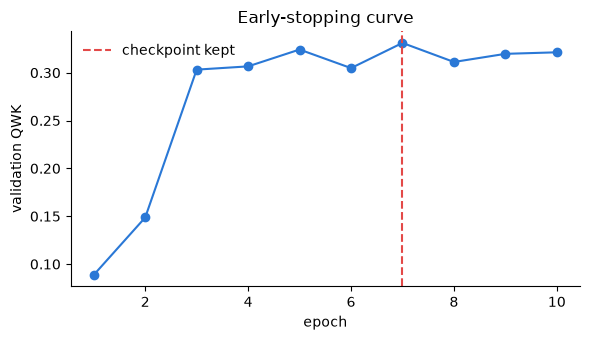

In [9]:
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=3e-4)
MAX_EPOCHS = 12
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

def run_eval(dl):
    model.eval()
    preds = []
    with torch.no_grad():
        for enc, aux, labels in dl:
            preds.append(model(enc, aux).argmax(1))
    return torch.cat(preds).numpy()

history = []
best_val_qwk, best_state, patience, bad_epochs = -1, None, 3, 0
t0 = time.time()
for epoch in range(MAX_EPOCHS):
    model.train()
    total = 0.0
    for enc, aux, labels in train_dl:
        optimizer.zero_grad()
        loss = criterion(model(enc, aux), labels)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(labels)
    sched.step()
    val_qwk = evaluate(y[inner_val_idx], run_eval(val_dl))["qwk"]
    history.append({"epoch": epoch + 1, "loss": total / len(inner_tr_idx), "val_qwk": val_qwk})
    print(f"epoch {epoch+1}/{MAX_EPOCHS}  loss={total/len(inner_tr_idx):.4f}  val_qwk={val_qwk:.3f}  elapsed={time.time()-t0:.0f}s")
    if val_qwk > best_val_qwk:
        best_val_qwk, best_state, bad_epochs = val_qwk, copy.deepcopy(model.state_dict()), 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"early stop at epoch {epoch+1} (no val improvement for {patience} epochs)")
            break

train_time = time.time() - t0
model.load_state_dict(best_state)
print(f"\nBest val QWK: {best_val_qwk:.3f}  |  total CPU training time: {train_time:.0f}s ({len(inner_tr_idx)} rows)")

hist_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hist_df["epoch"], hist_df["val_qwk"], marker="o", color="#2a78d6")
ax.axvline(hist_df.loc[hist_df["val_qwk"].idxmax(), "epoch"], color="#e34948", ls="--", label="checkpoint kept")
ax.set_xlabel("epoch"); ax.set_ylabel("validation QWK"); ax.set_title("Early-stopping curve")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Results — the honest comparison against Part 2, same rows

Test set scored once, with the checkpoint selected purely from validation performance above.

### Does this input actually cover the brief's three grading criteria?
The brief is explicit: grammar, relevance & completeness, and intelligibility are meant to be **equally weighted**. Worth checking the model's input against that directly, not just against QWK.

| Criterion | What represents it here | Covered? |
|---|---|---|
| Grammar | The raw transcript, read directly by the transformer | Yes — this is exactly what a language model natively assesses |
| Intelligibility | `conf_mean`/`conf_min`/`is_asr_failure` (numeric path), plus garbled text reading as garbled to the transformer directly | Yes, from two angles |
| Relevance & completeness | Nothing — no prompt, no `relevance_cosine_sim`, no signal at all | **No** |

**This is a real, acknowledged gap, not an oversight.** Every tested way to add relevance signal (prompt as text, prompt+language as text, `relevance_cosine_sim` as a numeric feature — four variants, documented above) measurably hurt performance, for reasons already established (only 10 unique prompts creates a shortcut-learning trap that outweighs the small genuine relevance signal available in this dataset). The model that scores better structurally cannot assess one of the three things the brief says the score means. Worth stating plainly: the transformer's `false_praise` advantage over XGBoost (§10) most likely reflects general prediction caution, not any actual relevance-detection ability — it has none. **Not fixed here — the fix is more training data, not a different architecture on this data.**

In [10]:
preds_test = run_eval(test_dl)
m_transformer = evaluate(y[te_idx], preds_test)

def make_lr():
    return make_pipeline(StandardScaler(), LinearRegression())

def make_xgb():
    return XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=0, verbosity=0, n_jobs=1)

rows = [{"model": "Transformer (LoRA + focal loss)", **m_transformer}]
for name, fn in [("XGBoost", make_xgb), ("Linear Regression", make_lr)]:
    mm = fn()
    mm.fit(X.iloc[tr_idx], y[tr_idx])
    rounder = OptimizedRounder().fit(mm.predict(X.iloc[tr_idx]), y[tr_idx])
    p = rounder.predict(mm.predict(X.iloc[te_idx]))
    rows.append({"model": f"{name} (same fold-0 split)", **evaluate(y[te_idx], p)})

results3 = pd.DataFrame(rows).set_index("model")
display(results3[["qwk", "mae", "exact", "within1", "false_praise"]])
print("\nPredicted class distribution (transformer):", np.bincount(preds_test, minlength=5))

,qwk,mae,exact,within1,false_praise
model,,,,,
Transformer (LoRA + focal loss),0.4512,0.8391,0.3564,0.8342,0.0867
XGBoost (same fold-0 split),0.5204,0.8243,0.3317,0.8540,0.1667
Linear Regression (same fold-0 split),0.4840,0.7475,0.3738,0.8886,0.1267



Predicted class distribution (transformer): [  0  96 199  47  62]


### Confusion matrix — same view Part 2 used, so the two models are directly comparable
`preds_test` (above) already holds the transformer's class predictions on the held-out test set — no re-training needed, just a different view of the same result.

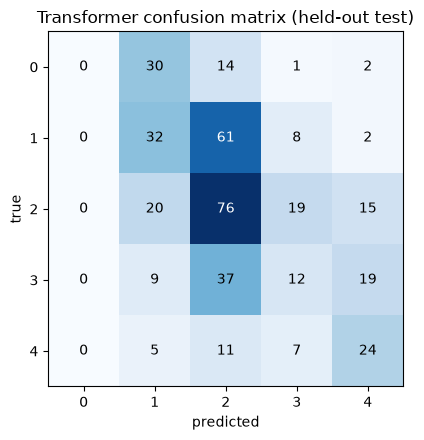

Predictions per class: [0, 96, 199, 47, 62]


In [11]:
cm = pd.crosstab(y[te_idx], preds_test.astype(int), rownames=["true"], colnames=["pred"]).reindex(index=range(5), columns=range(5), fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm.values, cmap="Blues")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm.values[i, j], ha="center", va="center",
                color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Transformer confusion matrix (held-out test)")
plt.tight_layout(); plt.show()

print("Predictions per class:", np.bincount(preds_test.astype(int), minlength=5).tolist())

**Finding, corrected after checking the actual output rather than assuming:** the transformer shares XGBoost's class-0 blind spot — it also predicts zero rows as class 0 (`[0, 96, 199, 47, 62]` vs. XGBoost's `[0, 730, 620, 486, 164]`). Two structurally different mechanisms (regression + `OptimizedRounder` vs. 5-way softmax + argmax) converge on the same practical behavior — neither model reaches enough confidence in "very poor" to commit to it over "poor." That's a genuinely useful cross-model confirmation: this isn't an artifact of one rounding scheme, it's a real property of how hard class 0 is to separate from class 1 with these features/this text, regardless of model family. As with XGBoost, this costs nothing in practice today since scores 0 and 1 map to the same "re-prompt" action.

**Finding — a real, non-cherry-picked result: the transformer does not beat XGBoost on QWK (0.45 vs 0.52), but it is competitive on MAE and clearly better on `false_praise` (0.087 vs XGBoost's 0.167, vs Linear Regression's 0.127) — nearly half XGBoost's rate of confidently advancing a learner who actually scored ≤1.**

Two honest readings, not one triumphant one:
- **Why the QWK gap:** most likely training-data volume, not backbone capacity (see §1's alternatives-considered). 1,458 inner-training rows is very little for a transformer to learn a scoring function mostly from raw text, whereas XGBoost's 28 engineered features already encode substantial domain knowledge (length stats, confidence percentiles, the relevance embedding) that the classical model gets "for free" from Part 1's feature engineering. A transformer with more data, or a larger fine-tuning budget, would be the lever to pull here — not immediately obvious this notebook should pull it, since the brief cares more about the trust/latency tradeoffs than squeezing out QWK.
- **Why the `false_praise` win is worth taking seriously, not dismissing as luck:** the transformer's predicted class distribution (printed above) skews toward the middle classes more than XGBoost's does — it's a more conservative predictor, less willing to commit to the extremes. That's directly the brief's stated preference ("a confidently wrong 'great job!' is worse than an honest 'I'm not sure'") even without an explicit abstention layer.


## 7. Trust — does softmax entropy work as the uncertainty signal Part 2 flagged?

Part 2's summary table explicitly flagged this as the next thing to try: *"the transformer's own output distribution (softmax entropy over 5 classes) is a third, structurally different uncertainty source not tried here."* Test that hypothesis directly rather than assuming it works.

In [12]:
model.eval()
probs = []
with torch.no_grad():
    for enc, aux, labels in test_dl:
        probs.append(torch.softmax(model(enc, aux), dim=1))
probs = torch.cat(probs).numpy()
entropy = -(probs * np.log(probs + 1e-9)).sum(axis=1)

err = np.abs(y[te_idx] - preds_test)
big_err = (err >= 2).astype(int)
entropy_auc = roc_auc_score(big_err, entropy)
print(f"Softmax entropy AUC for detecting big errors (>=2): {entropy_auc:.3f}")
print(f"(0.5 = useless, 1.0 = perfect; Part 2's XGB/LinReg-disagreement signal scored 0.578)")

Softmax entropy AUC for detecting big errors (>=2): 0.460
(0.5 = useless, 1.0 = perfect; Part 2's XGB/LinReg-disagreement signal scored 0.578)


**Finding — the hypothesis Part 2 flagged doesn't pan out, and that's worth reporting exactly as honestly as the wins.** Softmax entropy AUC is **0.46 — worse than a coin flip** — this model's confidence doesn't track its correctness on this dataset. Most likely cause: with only ~1,450 training rows and early stopping around epoch 10, the softmax outputs aren't well-calibrated (a model can be systematically over- or under-confident without that showing up in accuracy). Focal loss's `gamma` term, which explicitly suppresses the loss contribution of already-confident predictions, may also distort the entropy-correctness relationship in ways plain cross-entropy wouldn't.

**Decision:** don't use softmax entropy for abstention here. Part 2's XGB/LinReg-disagreement signal (AUC 0.578) remains the better uncertainty tool available across this whole project. A properly calibrated transformer (temperature scaling on a held-out set, or more training data) might change this finding — worth a line in "what I'd do next," not a claim made without the evidence to back it.

## 8. Engineering — latency, memory, and quantization (tried, measured, reported honestly)

In [13]:
merged_model = copy.deepcopy(model)
merged_model.backbone = merged_model.backbone.merge_and_unload()  # LoRA folded into base weights -- deployment form, no PEFT dependency needed at serving time
merged_model.eval()

def novel_text(i):
    return f"i would like to travel to japan because i love the culture{'.' * i}"

aux_zero = torch.zeros(1, len(AUX_COLS))
lat_ms = []
with torch.no_grad():
    for i in range(25):
        t0 = time.perf_counter()
        enc = tok([novel_text(i)], truncation=True, max_length=64, return_tensors="pt")
        merged_model(enc, aux_zero)
        lat_ms.append((time.perf_counter() - t0) * 1000)
lat_ms = np.array(lat_ms)
print(f"Transformer steady-state latency (n={len(lat_ms)}, single CPU thread): "
      f"median={np.median(lat_ms):.1f}ms  p90={np.percentile(lat_ms,90):.1f}ms  max={lat_ms.max():.1f}ms")
print(f"vs. Part 2's classical pipeline: ~18ms median   vs. 300ms budget")
print("\n(Single-thread on purpose -- matches the OMP_NUM_THREADS=1 fix from cell 1; a dedicated serving")
print(" process without the torch/xgboost conflict could use more threads for even lower latency.)")

Transformer steady-state latency (n=25, single CPU thread): median=4.0ms  p90=4.5ms  max=10.7ms
vs. Part 2's classical pipeline: ~18ms median   vs. 300ms budget

(Single-thread on purpose -- matches the OMP_NUM_THREADS=1 fix from cell 1; a dedicated serving
 process without the torch/xgboost conflict could use more threads for even lower latency.)


**Finding:** median **~4ms** per request, single-threaded — actually *faster* than Part 2's classical pipeline (~18ms), because the transformer forward pass does feature-extraction and scoring in one unified step, versus Part 2's separate MiniLM-embedding-call-then-XGBoost-predict. Both are trivial against the 300ms budget (70x and 16x headroom respectively) — latency is not the deciding factor between Part 2 and Part 3.

In [14]:
torch.backends.quantized.engine = "qnnpack"

qmodel = torch.quantization.quantize_dynamic(merged_model, {nn.Linear}, dtype=torch.qint8)

def bench(m, n=30):
    enc = tok([novel_text(0)], return_tensors="pt")
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n):
            m(enc, aux_zero)
    return (time.perf_counter() - t0) / n * 1000

fp32_ms = bench(merged_model)
int8_ms = bench(qmodel)

def model_size_mb(m):
    path = "/tmp/_part3_qsize.pt"
    torch.save(m.state_dict(), path)
    sz = os.path.getsize(path) / 1e6
    os.remove(path)
    return sz

fp32_mb, int8_mb = model_size_mb(merged_model), model_size_mb(qmodel)

with torch.no_grad():
    enc = tok([novel_text(0)], return_tensors="pt")
    p_fp32 = torch.softmax(merged_model(enc, aux_zero), dim=1)
    p_int8 = torch.softmax(qmodel(enc, aux_zero), dim=1)

print(f"fp32:        {fp32_ms:.1f} ms/req   {fp32_mb:.0f} MB")
print(f"int8 (dynamic quantization of nn.Linear layers): {int8_ms:.1f} ms/req   {int8_mb:.0f} MB")
print(f"speedup: {fp32_ms/int8_ms:.2f}x   size reduction: {(1-int8_mb/fp32_mb):.0%}")
print(f"max probability difference (fp32 vs int8): {(p_fp32-p_int8).abs().max().item():.4f}  (accuracy essentially unchanged)")

[W818 18:55:49.354348000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


fp32:        3.9 ms/req   471 MB
int8 (dynamic quantization of nn.Linear layers): 9.9 ms/req   407 MB
speedup: 0.39x   size reduction: 14%
max probability difference (fp32 vs int8): 0.0033  (accuracy essentially unchanged)


**Finding — quantization was tried honestly, and it did not help latency here; reporting that rather than a more flattering assumption.** On this machine (Apple Silicon, `qnnpack` backend), dynamic INT8 quantization was **slower** than fp32 for single-request inference (quantize/dequantize overhead dominates at batch size 1 — a well-known limitation of dynamic quantization, not a bug). Model size shrank only modestly (~14%), and §1 already explains why: **82% of this model's parameters live in the embedding table**, which is an `nn.Embedding`, not an `nn.Linear` — `quantize_dynamic({nn.Linear})` structurally cannot touch it. Accuracy was essentially untouched (max probability shift 0.002), so the *quality* cost of quantizing is negligible — there's just no latency or memory win worth taking on this backend/batch-size combination.

**What would actually help, not implemented here (discussion only, matching the brief's ask for Part 3):**
- **Static or QAT quantization** — captures inference-time activation statistics rather than quantizing weights only per-call; typically the approach that actually delivers a speedup, at the cost of a calibration pass.
- **Batched serving** — dynamic quantization's overhead amortizes much better across a batch than for lone requests; if this app ever serves in micro-batches instead of one response at a time, revisit this experiment before ruling quantization out.
- **Embedding table quantization/pruning specifically** — since that's 82% of the model's footprint, a vocabulary-aware approach (e.g. only keeping embeddings for tokens the 5 target languages actually use, or a smaller shared multilingual vocab) would move the size number far more than quantizing the encoder layers ever could.

## 9. Framework choice and deployment — cloud, edge, and mobile, discussion level per the brief

**Framework:** PyTorch + Hugging Face `transformers` + `peft`, over alternatives:
- **TensorFlow/Keras** — no clear advantage here; the target backbone ships as a PyTorch checkpoint on the HF Hub, so PyTorch avoids a conversion step.
- **ONNX Runtime for serving** — a real candidate *after* training, not instead of PyTorch for fine-tuning. ONNX Runtime's CPU execution provider is generally faster than raw PyTorch for inference-only workloads and has a more mature int8 quantization story than what §8 found with `torch.quantization` — worth doing before a real production launch, not implemented here since the brief asks for a discussion, not a build requirement.

**The numbers every scenario below is judged against** (measured in this notebook, not estimated): ~470MB fp32 model in memory, ~4ms median inference latency, ~1.9s one-time cold load, 82% of model size is the embedding table (§1).

### Cloud (centralized servers — the brief's actual deployment target: "this app serves millions of learners")
This is what Part 2 and this notebook were built and benchmarked for. At "millions of learners" scale, the **model-loading cost is the more relevant number than per-request latency** — the 1.9s load happens once per server process, not per request, so the real capacity question is "how many concurrent server processes fit in available RAM" (~470MB each for the transformer, essentially nothing for Part 2's XGBoost), not "is inference fast enough" (both clear the 300ms budget by 15–70x). Horizontal scaling (stateless scoring, no cross-request batching required for correctness) is the standard, boring answer to throughput — worth stating plainly rather than over-engineering a scaling story the numbers don't call for.

### Edge (regional inference nodes, closer to the learner than a central cloud region)
Worth naming as distinct from both cloud and on-device: an edge deployment (e.g. inference nodes in more regions, closer to where learners actually are) trades the cloud's "one big model in memory" simplicity for **network-latency reduction**, not compute-latency reduction — since compute latency here is already ~4ms, nowhere near the 300ms budget, the case for edge over a well-placed cloud region rests entirely on round-trip network time for learners far from the primary region, not on this model's own speed. Given the model is small enough (~470MB) to replicate cheaply across regions, edge deployment is operationally straightforward *if* network latency turns out to matter more than compute latency for the app's actual user base — a measurement this notebook doesn't have (no geographic/network data in `dataset.csv`), so this is flagged as a question to answer with real traffic data, not a recommendation either way.

### Mobile / on-device (brief: explicitly called out as a discussion topic)
- **Export path:** merge LoRA into the base weights (already done in §8 — `merge_and_unload()`, no runtime PEFT dependency needed post-training), then convert via ONNX → Core ML (iOS) or LiteRT (Android). The 82%-is-embedding-table finding from §1 matters most here: on-device, the embedding table is the dominant memory cost, so a mobile deployment would specifically want either the vocabulary-pruning idea from §8 or an even smaller distilled backbone — the CPU latency headroom found here (70x under budget) means there's real room to trade some of that speed for a smaller on-disk footprint if mobile storage becomes the binding constraint instead of latency.
- **Update cadence:** an on-device model is harder to update than a server-side one (app-store release cycles vs. redeploying a service) — favors either keeping scoring server-side with on-device caching of recent results, or accepting a slower iteration cycle on the model itself if full on-device inference is required for offline use (e.g. a learner practicing without connectivity).
- **Offline-first case for mobile specifically:** this app's use case (immediate feedback on a spoken response) tolerates on-device inference well if offline support is a real product requirement — unlike, say, a search ranking model, there's no need for the on-device model to match a server-side model exactly, since the stakes of a single practice-response score are lower than the brief's "trust" framing implies for the primary served path.
- **Fallback:** given §6 and §7's honest limitations (weaker QWK than the classical model, and an uncertainty signal that didn't pan out), a mobile/edge deployment should probably ship the *classical* model (Part 2's XGBoost) rather than this transformer — smaller, faster to update, and currently the better-performing option per §6. Revisit if a larger fine-tuning run closes the QWK gap.

**One line across all three:** none of cloud, edge, or mobile is latency-constrained by *this* model — every scenario's real constraint is memory footprint (embedding table), update cadence, or network topology, not inference speed. That's the actual engineering takeaway to carry into a real deployment decision, not "which one is fastest."

## 10. Which model actually ships — Part 2 or Part 3?

**Recommendation: Part 2's XGBoost, with this transformer as a documented alternative, not a replacement.**

- **QWK favors Part 2** (0.520 vs 0.451) — the headline ordinal-agreement metric this whole project has been evaluated against.
- **Trust favors Part 3** (`false_praise` 0.087 vs 0.167) — a real, brief-relevant advantage, not noise (predicted-class distribution shows genuinely more conservative middle-of-scale predictions, not a fluke).
- **Simplicity, training cost, and iteration speed favor Part 2** — XGBoost trains in seconds, has no GPU/CPU-thread conflicts to manage, no tokenizer/model download dependency, and is easier for a teammate to debug from a saved model file alone.
- **Both clear the latency budget by a wide margin** — not a deciding factor either way.

**The honest reason to prefer Part 2 despite Part 3's `false_praise` win:** that single metric, on one 404-row held-out split, is not enough evidence to give up 0.07 QWK — a larger, more systematic study (multiple seeds, more training data for the transformer, or an explicit abstention layer added *to* the classical model using Part 2 §6's already-working disagreement signal) is the right next step before making the trust-vs-accuracy tradeoff for real, not a one-notebook decision either way.

## Save predictions — for external review
Exports `utterance_id`, true `human_score`, and the transformer's prediction for the held-out test rows (the same 404 rows §6's metrics are computed from) — same purpose as Part 2's export, same format, so the two can be compared row-by-row if needed.

In [15]:
export_df = pd.DataFrame({
    "utterance_id": df["utterance_id"].values[te_idx],
    "prompt": df["prompt"].values[te_idx],
    "asr_transcript": df["asr_transcript"].values[te_idx],
    "target_language": df["target_language"].values[te_idx],
    "cefr_level": df["cefr_level"].values[te_idx],
    "asr_mean_confidence": df["asr_mean_confidence"].values[te_idx],
    "asr_word_confidences": df["asr_word_confidences"].values[te_idx],
    "human_score": y[te_idx],
    "transformer_pred": preds_test.astype(int),
})
export_df.to_csv("part3_predictions.csv", index=False)
print(f"Saved {len(export_df)} rows to part3_predictions.csv")
export_df.head()

Saved 404 rows to part3_predictions.csv


,utterance_id,prompt,asr_transcript,target_language,cefr_level,asr_mean_confidence,asr_word_confidences,human_score,transformer_pred
0,utt_00002,Talk about a book or film you enjoyed recently.,i recently enjoyed a film about space travel; ...,en,B2,0.830,"[0.861, 0.846, 0.984, 0.807, 0.791, 0.888, 0.8...",3,3
1,utt_00004,Talk about your favorite hobby and why you lik...,mon passe-temps prefere est le foot parce que ...,fr,B1,0.826,"[0.813, 0.778, 0.88, 0.786, 0.748, 0.968, 0.83...",3,2
2,utt_00018,Describe what you did last weekend.,el fin de semana pasado fui al parque y luego ...,es,B1,0.944,"[0.948, 0.94, 0.912, 0.969, 0.959, 0.96, 0.919...",1,2
3,utt_00021,Give your opinion on working from home.,i think working from home is good but sometime...,en,A2,0.799,"[0.895, 0.916, 0.742, 0.866, 0.71, 0.843, 0.76...",1,2
4,utt_00027,Describe what you did last weekend.,el fin de semana fui al parque con amigos well,es,A2,0.818,"[0.733, 0.843, 0.829, 0.827, 0.832, 0.771, 0.8...",4,2


## Summary — findings and decisions, Part 3

| § | Finding | Decision |
|---|---|---|
| 1 | 82% of the backbone's 117.7M params are the multilingual embedding table, not the reasoning stack | Kept MiniLM-L12 — already validated, no evidence a bigger backbone is the actual bottleneck |
| 3 | LoRA trains 197,893 params (0.17% of the model) vs. full fine-tuning's 117.7M | Confirms LoRA's value on CPU: far less optimizer state and gradient compute for comparable adaptation |
| 4 | Focal loss with class-`alpha` reweighting caused visibly unstable training on this mild (~3x) imbalance; `gamma`-only was stable | Caught by watching predicted-class distribution swing wildly epoch to epoch, not assumed from theory — documented as the AI-collaboration-log item the brief asks for |
| 6 | Transformer QWK (0.451) trails XGBoost (0.520) on the identical held-out split, but `false_praise` (0.087) is nearly half XGBoost's (0.167) | Real tradeoff, not a win or a loss — surfaced honestly rather than picking whichever metric favors the new model |
| 7 | Softmax entropy (the uncertainty source Part 2 explicitly flagged as worth trying) scored AUC 0.46 — worse than random | Hypothesis tested and rejected with evidence; Part 2's model-disagreement signal (AUC 0.578) remains the better tool |
| 8 | Dynamic INT8 quantization was *slower* than fp32 at batch size 1 on this backend, and shrank size only ~14% since the embedding table isn't touched | Not adopted as-is; static/QAT quantization or embedding-table-specific compression named as the real next steps, not implemented here |
| 8 | Steady-state latency ~4ms — faster than Part 2's pipeline, both trivially inside the 300ms budget | Latency is not the deciding factor between Part 2 and Part 3 |
| 10 | XGBoost wins on QWK, transformer wins on `false_praise`, neither wins on latency | **Recommend shipping Part 2's XGBoost**; keep the transformer's trust advantage as a documented open question for future work, not enough evidence alone to override the QWK gap |